importing all the necessary libraries

In [120]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

data collection and processing

In [131]:
# extracting the file
df = pd.read_csv("loan_data.csv")

In [132]:
# extracting the number of rows and columns
df.shape

(381, 13)

In [133]:
# checking the sample of our dataframe
df.sample(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
330,LP002690,Male,No,0,Graduate,No,2500,0.0,55.0,360.0,1.0,Semiurban,Y
206,LP002055,Female,No,0,Graduate,No,3166,2985.0,132.0,360.0,NaN,Rural,Y
364,LP002893,Male,No,0,Graduate,No,1836,33837.0,90.0,360.0,1.0,Urban,N
253,LP002287,Female,No,0,Graduate,No,1500,1800.0,103.0,360.0,0.0,Semiurban,N
228,LP002180,Male,No,0,Graduate,Yes,6822,0.0,141.0,360.0,1.0,Rural,Y


In [134]:
# mathematical atrributes of the dataframe
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [135]:
# checking for missing values
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [136]:
# dropping the missing vlaues
df = df.dropna()

In [137]:
# rechecking missing values
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [139]:
# label encoding
df.replace({"Loan_Status":{'Y':1,'N':0}}, inplace=True)

In [140]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1


In [141]:
#dependent column value
df['Dependents'].value_counts()

Dependents
0     194
2      47
1      43
3+     24
Name: count, dtype: int64

In [142]:
df = df.replace(to_replace='3+', value=4)

In [143]:
df['Dependents'].value_counts()

Dependents
0    194
2     47
1     43
4     24
Name: count, dtype: int64

data visualization

<Axes: xlabel='Education', ylabel='count'>

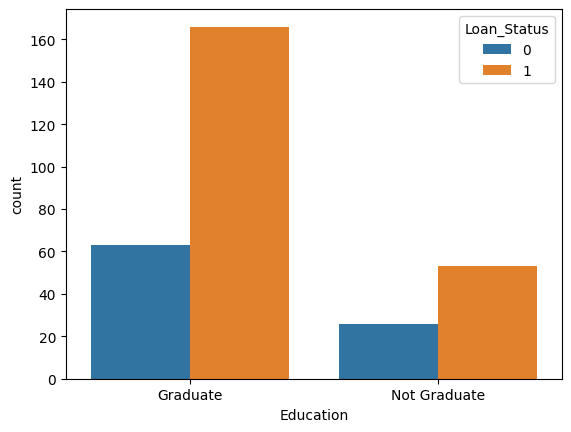

In [144]:
# education vs loan status
sns.countplot(x='Education', hue='Loan_Status',data=df)

<Axes: xlabel='Married', ylabel='count'>

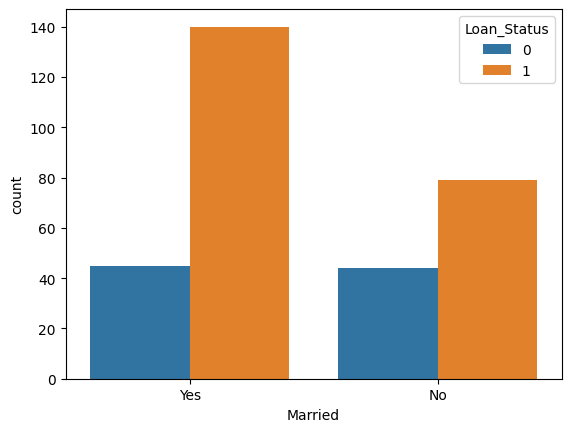

In [145]:
# marriage vs loan status
sns.countplot(x='Married', hue='Loan_Status',data=df)

In [147]:
# coverting categorical column into numerical column
df.replace({"Married":{'Yes':1,'No':0},"Gender":{'Male':1,'Female':0},"Self_Employed":{'Yes':1,'No':0},"Property_Area":{'Rural':0,'Semiurban':1,'Urban':2},"Education":{'Graduate':1,'Not Graduate':0}}, inplace=True)

In [148]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
1,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
2,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
3,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1
4,LP001013,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,2,1


In [151]:
# dropping column loan_id and seperating label 
x = df.drop(columns=['Loan_ID','Loan_Status'],axis=1)
y = df['Loan_Status']

In [152]:
print(x)
print(y)

     Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        1          1          1              0             4583   
1         1        1          0          1              1             3000   
2         1        1          0          0              0             2583   
3         1        0          0          1              0             6000   
4         1        1          0          0              0             2333   
..      ...      ...        ...        ...            ...              ...   
376       1        1          4          1              0             5703   
377       1        1          0          1              0             3232   
378       0        0          0          1              0             2900   
379       1        1          4          1              0             4106   
380       0        0          0          1              1             4583   

     CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_Hi

train test split

In [154]:
# splitting the data into training and testing set
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1,random_state=2,stratify=y)

In [156]:
x.shape, x_train.shape , x_test.shape

((308, 11), (277, 11), (31, 11))

Training model:

Support Vector Machine Model

In [157]:
# defining classifier
classifier = svm.SVC(kernel='linear')

In [159]:
#training the svm model
classifier.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


model evaluation

In [160]:
#checking the model accuracy
x_train_prediction = classifier.predict(x_train)

In [161]:
training_data_accuracy = accuracy_score(x_train_prediction,y_train)

In [164]:
print("Accuracy on training data" ,training_data_accuracy)

Accuracy on training data 0.8267148014440433


In [165]:
#checking the model accuracy on test data
x_test_prediction = classifier.predict(x_test)
training_data_accuracy = accuracy_score(x_test_prediction ,y_test)

In [166]:
print('Accuracy on test data:', training_data_accuracy) 

Accuracy on test data: 0.8064516129032258
